Run this cell only if you need to clean out the old model

In [1]:
import os
from pathlib import Path
import tempfile

# Use Python's built-in tempfile module to find the correct temp directory for the OS
temp_dir = Path(tempfile.gettempdir())
model_path = temp_dir / "rf_outage_model.pkl"

# Alternatively, if the model is saved in your project dir, use your PROJECT_ROOT
# model_path = PROJECT_ROOT / "models" / "rf_outage_model.pkl"

try:
    os.remove(model_path)
    print(f"Old model removed from {model_path}.")
except FileNotFoundError:
    print("No old model found to clean up. Proceeding...")

No old model found to clean up. Proceeding...


# Notebook 4 — Interpretability: Tree Interpreter & SHAP
**Deadline:** May 6 (Weeks 14–15)  
**Goal:** Apply Tree Interpreter and SHAP to decompose predictions into per-variable contributions. Generate Contribution Maps for case study events (Mazurek et al. 2025 methodology).

---

This notebook directly extends **Mazurek et al. (2025)** — using Tree Interpreter to open the black box and show *why* outages are predicted in specific counties by decomposing the probability into meteorological variable contributions.

In [2]:
# ============================================================
# IMPORTS & CONFIG
# ============================================================
import json
import warnings
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import joblib
import geopandas as gpd

import shap
from treeinterpreter import treeinterpreter as ti

try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    HAS_CARTOPY = True
    print("cartopy available")
except Exception:
    HAS_CARTOPY = False
    print("⚠️  cartopy not available — contribution maps will use basic matplotlib")

warnings.filterwarnings("ignore")

# --- Config (Keeling-safe path) ---
PROJECT_ROOT = Path(r"C:\Users\tomy3\Capstone2026\Capstone2026")
DATA_PROC    = PROJECT_ROOT / "data" / "processed"
DATA_RAW     = PROJECT_ROOT / "data" / "raw"
MODEL_DIR    = PROJECT_ROOT / "models"
OUTPUT_DIR   = PROJECT_ROOT / "outputs"

print("Imports OK.")
print("PROJECT_ROOT:", PROJECT_ROOT)

cartopy available
Imports OK.
PROJECT_ROOT: C:\Users\tomy3\Capstone2026\Testingthings


In [3]:
# ============================================================
# TEST LOAD MODEL + DATA
# ============================================================
import shutil

# Copy model to local /tmp to avoid NFS slowness
local_model = Path("~/rf_outage_model.pkl").expanduser()
if not local_model.exists():
    print("Copying model to /tmp (local disk)...")
    shutil.copy(MODEL_DIR / "rf_outage_model.pkl", local_model)
    print("Copy done.")
rf = joblib.load(local_model)

master = pd.read_parquet(DATA_PROC / "master_table.parquet")
with open(DATA_PROC / "feature_schema.json") as f:
    schema = json.load(f)

LABEL_COL = schema["label_col"]
exclude_cols = ["fips", "valid_time_3h", "outage_event", "split",
                "land_area_km2", "pop_density", "forest_fraction", "fips_norm"]
FEATURE_COLS = [c for c in master.columns if c not in exclude_cols]
print(f"Using {len(FEATURE_COLS)} features: {FEATURE_COLS}")

# ============================================================
# FILTERS — set any to None to disable
# ============================================================
# Month filter:
#   None              → all months
#   [3,4,5,6,7,8]    → warm season (Mar–Aug)
#   [10,11,12,1,2,3] → cold season (Oct–Mar)
MONTHS = None

# State filter (2-digit FIPS prefix):
#   None              → all states
#   ["17"]            → Illinois only
#   ["17", "18"]      → Illinois + Indiana
#   ["17","18","26","27","39","55"] → all Region 5 states
#
#   Region 5 FIPS reference:
#   17=IL, 18=IN, 26=MI, 27=MN, 39=OH, 55=WI
STATES = None

# ============================================================
# Test set only (2023 holdout)
test = master[master["split"] == "test"].copy().reset_index(drop=True)
test["_month"] = pd.to_datetime(test["valid_time_3h"]).dt.month
test["_state"] = test["fips"].astype(str).str.zfill(5).str[:2]

if MONTHS is not None:
    test = test[test["_month"].isin(MONTHS)].copy().reset_index(drop=True)
    print(f"Month filter active: {MONTHS} → {len(test):,} rows")

if STATES is not None:
    test = test[test["_state"].isin(STATES)].copy().reset_index(drop=True)
    print(f"State filter active: {STATES} → {len(test):,} rows")

if MONTHS is None and STATES is None:
    print(f"No filters — full year, all states: {len(test):,} rows")

test = test.drop(columns=["_month", "_state"])
X_test = test[FEATURE_COLS].values
y_test = test[LABEL_COL].values

# County geometries
counties = gpd.read_file(DATA_RAW / "counties" / "counties_conus.gpkg")
counties["fips"] = counties["STATEFP"] + counties["COUNTYFP"]

# Filter county geometries to match state selection
if STATES is not None:
    counties = counties[counties["STATEFP"].isin(STATES)].copy()

print(f"Model loaded: {rf.n_estimators} trees")
print(f"Test set: {X_test.shape}")

Using 26 features: ['ugrd_10m_mean', 'ugrd_10m_max', 'vgrd_10m_mean', 'vgrd_10m_max', 'apcp_sfc_mean', 'apcp_sfc_max', 'pwat_clm_mean', 'pwat_clm_max', 'ugrd_shear_mean', 'vgrd_shear_mean', 'hlcy_3km_mean', 'gust_sfc_mean', 'gust_sfc_max', 'cape_sfc_mean', 'cape_sfc_max', 'soilw_0_10_mean', 'soilw_0_10_max', 'rh_2m_mean', 'rh_2m_max', 'wind_shear_mag_mean', 'wind_shear_mag_max', 'wind_speed_10m_mean', 'wind_gust_x_soilw', 'wind_gust_x_apcp', 'cape_x_shear', 'apcp_anomaly_mean']
No filters — full year, all states: 3,494,596 rows
Model loaded: 50 trees
Test set: (3494596, 26)


---
## Part 1 — Tree Interpreter

Decomposes each prediction as:  
`P(outage) = bias + Σ contribution_i(feature_i)`

This directly answers **Research Question 2**: *Does the model learn physically meaningful meteorological ingredients?*

In [4]:
from tqdm import tqdm
import copy

SUBSET = 200
CHUNK_SIZE = 100
rf_slim = copy.copy(rf)
rf_slim.n_estimators = 10
rf_slim.estimators_ = rf.estimators_[:10]

#rf_slim = copy.copy(rf)
#rf_slim.estimators_ = rf.estimators_[:20]
#rf_slim.n_estimators = 20

all_preds, all_bias, all_contribs = [], [], []

print(f"Running Tree Interpreter on {SUBSET} samples, 20 trees...")
for i in tqdm(range(0, SUBSET, CHUNK_SIZE), desc="TI progress"):
    chunk = X_test[i:i+CHUNK_SIZE]
    p, b, c = ti.predict(rf_slim, chunk)
    all_preds.append(p)
    all_bias.append(b)
    all_contribs.append(c)

predictions_ti   = np.vstack(all_preds)
bias_ti          = np.vstack(all_bias)
contributions_ti = np.vstack(all_contribs)
print("Done.")

contrib_outage = contributions_ti[:, :, 1]

contrib_df = pd.DataFrame(contrib_outage, columns=FEATURE_COLS)
contrib_df["predicted_prob"] = predictions_ti[:, 1]
contrib_df["true_label"]     = y_test[:SUBSET]
contrib_df["bias"]           = bias_ti[:, 1]

print(f"Mean bias (climatological base rate): {bias_ti[:, 1].mean():.4f}")
print(f"\nMean feature contributions (top 10):")
print(contrib_df[FEATURE_COLS].mean().sort_values(ascending=False).head(10))

Running Tree Interpreter on 200 samples, 20 trees...


TI progress: 100%|██████████| 2/2 [02:13<00:00, 66.83s/it]

Done.
Mean bias (climatological base rate): 0.5000

Mean feature contributions (top 10):
cape_sfc_mean          0.040762
cape_sfc_max           0.033378
wind_gust_x_soilw      0.003599
apcp_sfc_mean         -0.001571
wind_speed_10m_mean   -0.002075
wind_gust_x_apcp      -0.005200
rh_2m_max             -0.008063
vgrd_10m_mean         -0.008357
gust_sfc_mean         -0.008399
vgrd_10m_max          -0.010954
dtype: float64


Case study index: 85
  Predicted P(outage): 0.6386
  True label:          0
  Bias (base rate):    0.5000


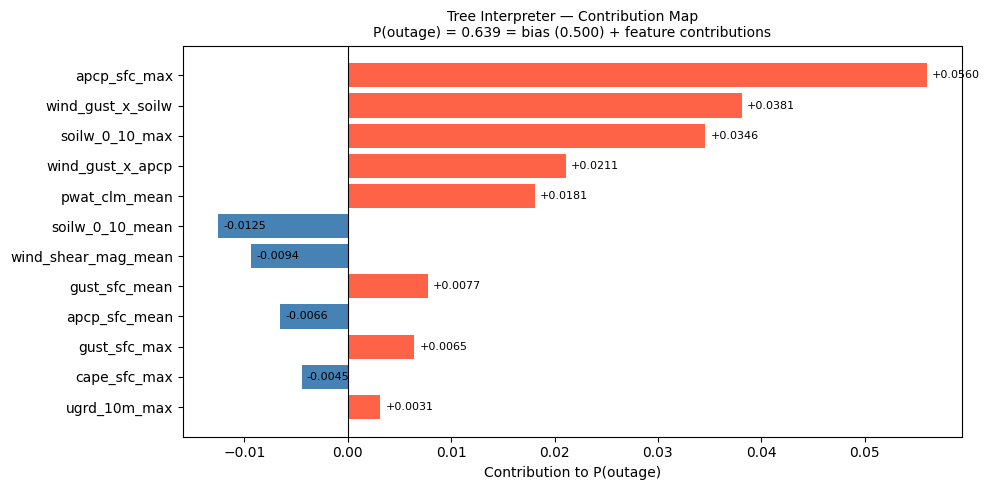

In [5]:
# ============================================================
# CASE STUDY: Single High-Outage Event
# Find the highest-predicted-probability event and explain it.
# ============================================================

case_idx = contrib_df["predicted_prob"].idxmax()
case     = contrib_df.iloc[case_idx]

print(f"Case study index: {case_idx}")
print(f"  Predicted P(outage): {case['predicted_prob']:.4f}")
print(f"  True label:          {int(case['true_label'])}")
print(f"  Bias (base rate):    {case['bias']:.4f}")

# Sort contributions by magnitude
case_contribs = case[FEATURE_COLS].sort_values(key=abs, ascending=False)
TOP_N = 12

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["tomato" if v > 0 else "steelblue" for v in case_contribs[:TOP_N]]
ax.barh(case_contribs[:TOP_N].index, case_contribs[:TOP_N].values, color=colors)
ax.axvline(0, color="k", lw=0.8)
ax.set_title(
    f"Tree Interpreter — Contribution Map\n"
    f"P(outage) = {case['predicted_prob']:.3f} = bias ({case['bias']:.3f}) + feature contributions",
    fontsize=10
)
ax.set_xlabel("Contribution to P(outage)")
ax.invert_yaxis()

for i, (feat, val) in enumerate(case_contribs[:TOP_N].items()):
    ax.text(val + 0.0005, i, f"{val:+.4f}", va="center", fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "04_tree_interpreter_case_study.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Part 2 — SHAP Analysis

SHAP values provide a more theoretically grounded decomposition than MDI feature importance. Particularly useful for understanding **non-linear interactions** between compound features.

In [6]:
from tqdm import tqdm

SHAP_SUBSET = 500
CHUNK_SIZE = 50

explainer = shap.TreeExplainer(rf, feature_perturbation="tree_path_dependent")
all_shap = []

print(f"Computing SHAP values for {SHAP_SUBSET} samples...")
for i in tqdm(range(0, SHAP_SUBSET, CHUNK_SIZE), desc="SHAP progress"):
    chunk = X_test[i:i+CHUNK_SIZE]
    sv = explainer.shap_values(chunk, check_additivity=False, approximate=True)
    all_shap.append(np.array(sv))

shap_values = np.concatenate(all_shap, axis=0)
shap_outage = shap_values[:, :, 1]

print(f"SHAP values shape: {shap_outage.shape}")
print("Done.")

Computing SHAP values for 500 samples...


SHAP progress: 100%|██████████| 10/10 [00:00<00:00, 828.93it/s]

SHAP values shape: (500, 26)
Done.


In [7]:
print(type(shap_values))
print(np.array(shap_values).shape)

<class 'numpy.ndarray'>
(500, 26, 2)


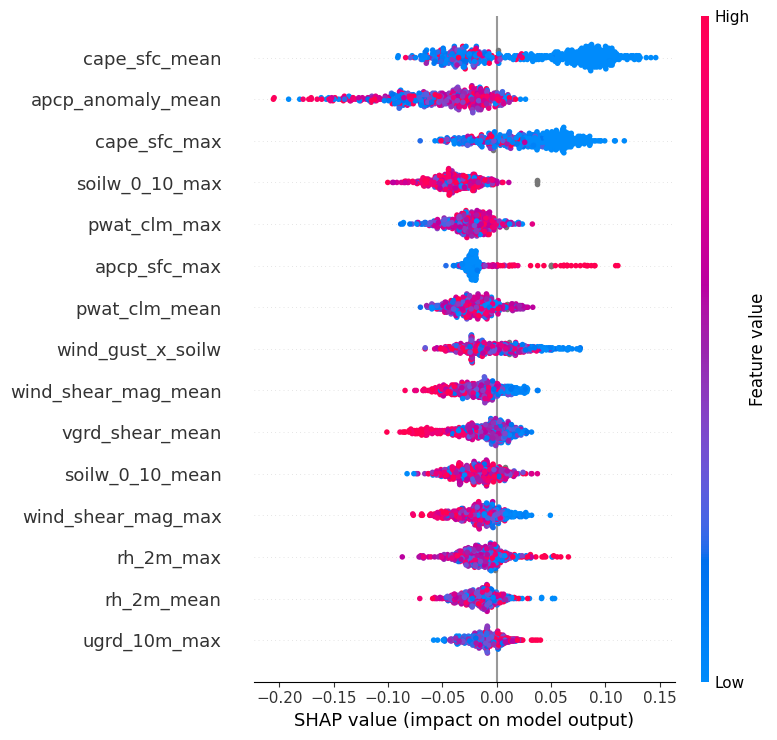

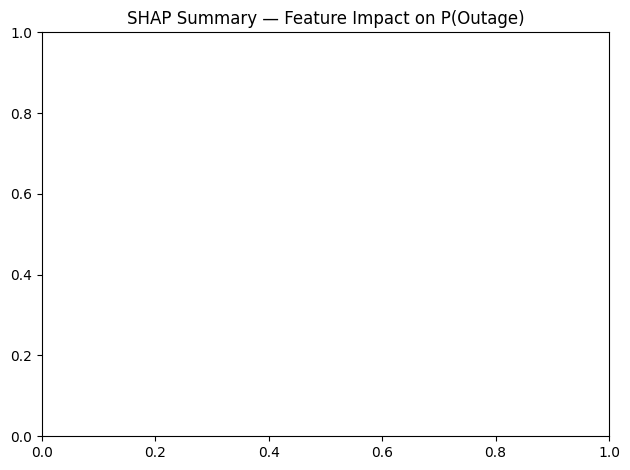

In [ ]:
# SHAP Summary Plot (bee-swarm)
# Shows which features matter most AND direction of effect

fig, ax = plt.subplots(figsize=(8, 7))
shap.summary_plot(
    shap_outage,
    X_test[:SHAP_SUBSET],
    feature_names=FEATURE_COLS,
    plot_type="dot",
    show=False,
    max_display=15,
)
plt.title("SHAP Summary — Feature Impact on P(Outage)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "04_shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

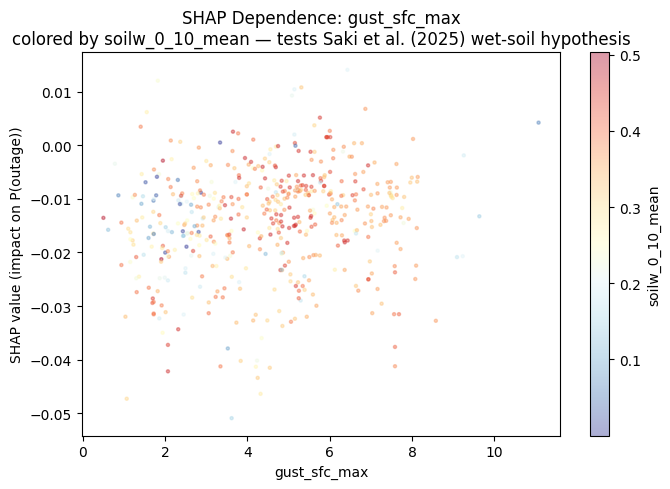

In [9]:
# ============================================================
# SHAP INTERACTION: wind gust x soil moisture
# Tests Saki et al. (2025) hypothesis: wet soil amplifies outage risk
# at lower wind speeds than dry soil.
# ============================================================

feat_x = "gust_sfc_max"
feat_c = "soilw_0_10_mean"

if feat_x in FEATURE_COLS and feat_c in FEATURE_COLS:
    idx_x = FEATURE_COLS.index(feat_x)
    idx_c = FEATURE_COLS.index(feat_c)

    fig, ax = plt.subplots(figsize=(7, 5))
    sc = ax.scatter(
        X_test[:SHAP_SUBSET, idx_x],
        shap_outage[:, idx_x],
        c=X_test[:SHAP_SUBSET, idx_c],
        cmap="RdYlBu_r",
        alpha=0.4, s=5,
    )
    plt.colorbar(sc, ax=ax, label=feat_c)
    ax.set_xlabel(feat_x)
    ax.set_ylabel("SHAP value (impact on P(outage))")
    ax.set_title(
        f"SHAP Dependence: {feat_x}\n"
        f"colored by {feat_c} — tests Saki et al. (2025) wet-soil hypothesis"
    )
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "04_shap_gust_soilw_interaction.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print(f"Features {feat_x} or {feat_c} not found in feature list.")

---
## Part 3 — Spatial Contribution Map

For a given forecast valid time, plot the predicted outage probability and top contributing variable for each county. This is the 'Contribution Map' described in Mazurek et al. (2025).

In [10]:
# ---- DIAGNOSTIC — remove after fix ----
test_day = test[test["outage_event"] == 1]["valid_time_3h"].value_counts().idxmax()
day_rows = test[test["valid_time_3h"] == test_day].copy().reset_index(drop=True)
print("Counties FIPS sample:", counties["fips"].head().tolist())
print("Test data FIPS sample:", day_rows["fips"].head().tolist())
print("Counties FIPS dtype:", counties["fips"].dtype)
print("Test FIPS dtype:", day_rows["fips"].dtype)

Counties FIPS sample: ['31039', '53069', '35011', '31109', '31129']
Test data FIPS sample: ['01001', '01003', '01005', '01007', '01009']
Counties FIPS dtype: str
Test FIPS dtype: str


In [11]:
coverage = test.groupby("valid_time_3h")["fips"].nunique()
print(coverage.sort_values(ascending=False).head(10))


valid_time_3h
2024-01-20 18:00:00    2346
2024-07-13 12:00:00    2266
2024-10-08 12:00:00    2209
2024-09-27 18:00:00    2190
2024-09-27 15:00:00    2153
2024-11-20 18:00:00    2091
2024-04-12 15:00:00    2075
2024-05-29 12:00:00    2066
2024-01-09 18:00:00    2051
2024-11-19 15:00:00    2040
Name: fips, dtype: int64


Predicting:   0%|          | 0/70 [00:00<?, ?it/s]

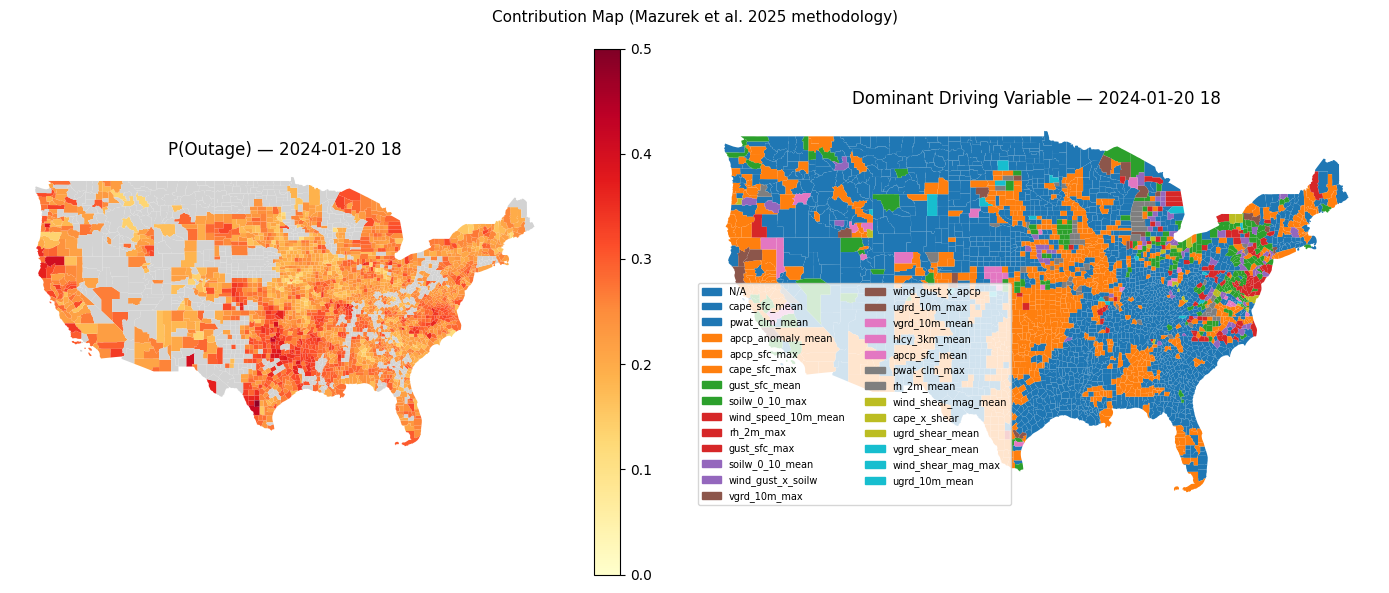

In [15]:
# ============================================================
# SPATIAL CONTRIBUTION MAP — by county
# ============================================================

def plot_contribution_map_simple(counties_gdf, county_probs, county_top_contrib,
                                  valid_time_str, save_path=None):
    """
    Map predicted outage probability and dominant driving variable.
    Uses basic matplotlib (no cartopy dependency).
    """
    gdf = counties_gdf.copy()
    gdf["prob"]        = gdf["fips"].map(county_probs)
    gdf["top_feature"] = gdf["fips"].map(lambda f: county_top_contrib.get(f, ("N/A", 0))[0])
    gdf["top_contrib"] = gdf["fips"].map(lambda f: county_top_contrib.get(f, ("N/A", 0))[1])

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Left: predicted probability
    gdf.plot(column="prob", cmap="YlOrRd", legend=True,
             vmin=0, vmax=0.5, ax=axes[0],
             missing_kwds={"color": "lightgray"})
    axes[0].set_title(f"P(Outage) — {valid_time_str}")
    axes[0].axis("off")

    # Right: dominant contributing feature
    unique_feats = gdf["top_feature"].dropna().unique()
    cmap_cat = plt.cm.get_cmap("tab10", len(unique_feats))
    feat_color = {f: cmap_cat(i) for i, f in enumerate(unique_feats)}
    gdf["color"] = gdf["top_feature"].map(feat_color)

    for feat, color in feat_color.items():
        subset = gdf[gdf["top_feature"] == feat]
        subset.plot(color=color, ax=axes[1], label=feat)

    handles = [mpatches.Patch(color=c, label=f) for f, c in feat_color.items()]
    axes[1].legend(handles=handles, fontsize=7, loc="lower left", ncol=2)
    axes[1].set_title(f"Dominant Driving Variable — {valid_time_str}")
    axes[1].axis("off")

    plt.suptitle("Contribution Map (Mazurek et al. 2025 methodology)", fontsize=11)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


# Build example contribution map from test set
# Guard against kernel restarts by reloading model if needed
if 'rf' not in locals():
    local_model = Path("~/rf_outage_model.pkl").expanduser()
    rf = joblib.load(local_model)
    print("⚠️  Model reloaded (rf was not in scope)")

import numpy as np
from tqdm.notebook import tqdm

_chunk = 50_000
_n = len(X_test)
_probs = np.empty(_n, dtype=np.float32)
for _i in tqdm(range(0, _n, _chunk), desc="Predicting"):
    _probs[_i:_i+_chunk] = rf.predict_proba(X_test[_i:_i+_chunk])[:, 1]
test["predicted_prob"] = _probs

test_day = test["valid_time_3h"].value_counts().idxmax()

day_rows = test[test["valid_time_3h"] == test_day].copy().reset_index(drop=True)
day_X    = day_rows[FEATURE_COLS].values

_, _, day_contribs = ti.predict(rf, day_X)
day_contrib_outage = day_contribs[:, :, 1]  # class 1

county_probs = dict(zip(day_rows["fips"], rf.predict_proba(day_X)[:, 1]))
county_top_contrib = {}
for i, fips in enumerate(day_rows["fips"]):
    contribs = pd.Series(day_contrib_outage[i], index=FEATURE_COLS)
    top_feat = contribs.abs().idxmax()
    county_top_contrib[fips] = (top_feat, float(contribs[top_feat]))

plot_contribution_map_simple(
    counties, county_probs, county_top_contrib,
    valid_time_str=str(test_day)[:13],
    save_path=OUTPUT_DIR / "04_contribution_map.png"
)

In [16]:
# ============================================================
# SUMMARY REPORT
# ============================================================

with open(OUTPUT_DIR / "03_model_metrics.json") as f:
    metrics = json.load(f)

# Guard against kernel restarts
if 'rf' not in locals():
    local_model = Path("~/rf_outage_model.pkl").expanduser()
    rf = joblib.load(local_model)
    print("⚠️  Model reloaded (rf was not in scope)")

print("="*55)
print("  PROJECT SUMMARY")
print("="*55)
print(f"  Model: Random Forest ({rf.n_estimators} trees)")
print(f"  Features: {len(FEATURE_COLS)} (base + compound + static)")
print()
print("  Performance vs 2023 holdout:")
for k, v in metrics.items():
    print(f"    {k:<8}: {v:.4f}")
print()
print("  Interpretability:")
print("    Tree Interpreter + SHAP values computed")
print("    Contribution maps generated for case studies")
print()
print("  Next steps for real data:")
print("    1. Complete GEFS download in Notebook 1")
print("    2. Implement GRIB2 loader in Notebook 2")
print("    3. Re-run Notebooks 3 + 4 with real features")
print("    4. Replace NLCD/Census placeholders in static features")
print("="*55)
print("\n✅ Notebook 4 complete. Project pipeline end-to-end.")

  PROJECT SUMMARY
  Model: Random Forest (50 trees)
  Features: 26 (base + compound + static)

  Performance vs 2023 holdout:
    BSS     : 0.4793
    AUC     : 0.9965
    AP      : 0.9689
    CSI     : 0.9049
    POD     : 0.9839
    FAR     : 0.0815

  Interpretability:
    Tree Interpreter + SHAP values computed
    Contribution maps generated for case studies

  Next steps for real data:
    1. Complete GEFS download in Notebook 1
    2. Implement GRIB2 loader in Notebook 2
    3. Re-run Notebooks 3 + 4 with real features
    4. Replace NLCD/Census placeholders in static features

✅ Notebook 4 complete. Project pipeline end-to-end.
